# Building a DCF Model (Systematic, Data-Driven)

This notebook walks through a professional, systematic discounted cash flow (DCF) build.
We will fetch company financial data online, normalize it into a clean history, and apply realistic assumptions to project free cash flow.

Key goals:
- explain the logic behind each step
- keep assumptions explicit and defensible
- produce a robust, reproducible valuation

## 1. DCF Logic in One Page

DCF values a business by estimating the cash it can generate in the future and discounting those cash flows back to today.

Core steps:
1. collect historical financials
2. convert accounting statements into free cash flow (FCF)
3. project FCF over a forecast horizon
4. estimate a terminal value for cash flows beyond the horizon
5. discount everything by a required return (WACC)
6. reconcile enterprise value to equity value

A DCF is only as good as its assumptions. We will keep them transparent and tie them to the history where possible.

In [31]:
from __future__ import annotations

from dataclasses import dataclass
from datetime import datetime
from typing import Iterable
from io import StringIO

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

SEC_HEADERS = {
    "User-Agent": "EEIF DCF Tutorial contact@example.com",
    "Accept-Encoding": "gzip, deflate",
}


def fetch_json(url: str) -> dict:
    response = requests.get(url, headers=SEC_HEADERS, timeout=30)
    response.raise_for_status()
    return response.json()


def fetch_yahoo_price(ticker: str) -> float | None:
    quote_url = f"https://query1.finance.yahoo.com/v7/finance/quote?symbols={ticker}"
    chart_url = (
        f"https://query1.finance.yahoo.com/v8/finance/chart/{ticker}"
        f"?range=5d&interval=1d&includePrePost=false&events=div%2Csplits"
    )
    headers = {"User-Agent": "Mozilla/5.0"}

    for url in (quote_url, chart_url):
        try:
            response = requests.get(url, headers=headers, timeout=30)
            response.raise_for_status()
            payload = response.json()
            if "quoteResponse" in payload:
                results = payload.get("quoteResponse", {}).get("result", [])
                if results and results[0].get("regularMarketPrice") is not None:
                    return float(results[0]["regularMarketPrice"])
            if "chart" in payload:
                result = payload["chart"]["result"][0]
                closes = result["indicators"]["quote"][0]["close"]
                closes = [value for value in closes if value is not None]
                if closes:
                    return float(closes[-1])
        except requests.RequestException:
            continue
    return None


def fetch_stooq_price(ticker: str) -> float | None:
    symbol = f"{ticker.lower()}.us"
    url = f"https://stooq.com/q/l/?s={symbol}&i=d"
    try:
        response = requests.get(url, headers={"User-Agent": "Mozilla/5.0"}, timeout=30)
        response.raise_for_status()
        if "apikey" in response.text.lower():
            return None
        frame = pd.read_csv(StringIO(response.text))
        if frame.empty:
            return None
        close_column = "Close" if "Close" in frame.columns else frame.columns[-2]
        latest_close = frame[close_column].dropna().iloc[-1]
        return float(latest_close)
    except (requests.RequestException, ValueError, IndexError):
        return None


def fetch_market_price(ticker: str) -> float | None:
    return fetch_yahoo_price(ticker) or fetch_stooq_price(ticker)


def get_cik_from_ticker(ticker: str) -> str:
    url = "https://www.sec.gov/files/company_tickers.json"
    data = fetch_json(url)
    for item in data.values():
        if item["ticker"].lower() == ticker.lower():
            return str(item["cik_str"]).zfill(10)
    raise ValueError(f"Ticker {ticker} not found in SEC list.")


def get_company_facts(cik: str) -> dict:
    url = f"https://data.sec.gov/api/xbrl/companyfacts/CIK{cik}.json"
    return fetch_json(url)


def extract_tag_series(facts: dict, tags: Iterable[str], unit: str = "USD") -> pd.Series:
    for tag in tags:
        tag_data = facts.get("facts", {}).get("us-gaap", {}).get(tag, {})
        if not tag_data:
            continue
        units = tag_data.get("units", {})
        if unit not in units:
            continue
        rows = units[unit]
        frame = pd.DataFrame(rows)
        if frame.empty:
            continue
        # Keep annual filings (form 10-K) and fiscal year values only.
        frame = frame[frame["form"].isin(["10-K", "20-F", "40-F"])].copy()
        frame["fy"] = frame["fy"].astype(int)
        frame = frame.sort_values("fy").drop_duplicates("fy", keep="last")
        series = pd.Series(frame["val"].values, index=frame["fy"])
        series.name = tag
        return series
    return pd.Series(dtype=float)


def coalesce_series(series_list: Iterable[pd.Series]) -> pd.Series:
    result = None
    for series in series_list:
        if series.empty:
            continue
        if result is None:
            result = series.copy()
        else:
            result = result.combine_first(series)
    return result if result is not None else pd.Series(dtype=float)


def safe_ratio(numerator: pd.Series, denominator: pd.Series) -> pd.Series:
    aligned = pd.concat([numerator, denominator], axis=1).dropna()
    if aligned.empty:
        return pd.Series(dtype=float)
    return aligned.iloc[:, 0] / aligned.iloc[:, 1]


def latest_value(series: pd.Series) -> float | None:
    if series.empty:
        return None
    return float(series.dropna().iloc[-1])


def clip(value: float, lower: float, upper: float) -> float:
    return min(max(value, lower), upper)


def build_financial_history(facts: dict) -> pd.DataFrame:
    revenue = coalesce_series([
        extract_tag_series(facts, ["RevenueFromContractWithCustomerExcludingAssessedTax", "Revenues"]),
        extract_tag_series(facts, ["SalesRevenueNet"]),
    ])

    operating_income = extract_tag_series(facts, ["OperatingIncomeLoss"])
    pre_tax_income = extract_tag_series(facts, ["IncomeLossFromContinuingOperationsBeforeIncomeTaxes"])
    interest_expense = extract_tag_series(facts, ["InterestExpense"])

    if operating_income.empty and not pre_tax_income.empty and not interest_expense.empty:
        ebit = pre_tax_income + interest_expense
    else:
        ebit = operating_income.combine_first(pre_tax_income)

    depreciation = coalesce_series([
        extract_tag_series(facts, ["DepreciationAndAmortization"]),
        extract_tag_series(facts, ["DepreciationDepletionAndAmortization"]),
    ])

    capex = coalesce_series([
        extract_tag_series(facts, ["PaymentsToAcquirePropertyPlantAndEquipment"]),
        extract_tag_series(facts, ["CapitalExpenditures"]),
    ])

    current_assets = extract_tag_series(facts, ["AssetsCurrent"])
    current_liabilities = extract_tag_series(facts, ["LiabilitiesCurrent"])

    history = pd.DataFrame({
        "Revenue": revenue,
        "EBIT": ebit,
        "Depreciation": depreciation,
        "Capex": capex,
        "CurrentAssets": current_assets,
        "CurrentLiabilities": current_liabilities,
    }).sort_index()

    return history


def impute_by_ratio(df: pd.DataFrame, column: str, ratio_col: str, lower: float, upper: float) -> tuple[pd.DataFrame, float | None, int]:
    ratios = safe_ratio(df[column], df[ratio_col]).replace([np.inf, -np.inf], np.nan).dropna()
    if ratios.empty:
        return df, None, 0
    ratio_value = clip(float(ratios.median()), lower, upper)
    mask = df[column].isna() & df[ratio_col].notna()
    df.loc[mask, column] = df.loc[mask, ratio_col] * ratio_value
    return df, ratio_value, int(mask.sum())


def finalize_history(history: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    cleaned = history.copy()
    cleaned = cleaned[cleaned["Revenue"].notna()].copy()

    notes = []
    for column, bounds in {
        "EBIT": (-0.20, 0.45),
        "Depreciation": (0.00, 0.15),
        "Capex": (0.00, 0.25),
    }.items():
        cleaned, ratio_value, count = impute_by_ratio(cleaned, column, "Revenue", *bounds)
        notes.append({
            "Metric": column,
            "Imputed_Count": count,
            "Applied_Ratio": ratio_value,
        })

    cleaned["NWC"] = cleaned["CurrentAssets"] - cleaned["CurrentLiabilities"]
    cleaned, nwc_ratio, nwc_count = impute_by_ratio(cleaned, "NWC", "Revenue", -0.05, 0.30)
    notes.append({
        "Metric": "NWC",
        "Imputed_Count": nwc_count,
        "Applied_Ratio": nwc_ratio,
    })

    cleaned["DeltaNWC"] = cleaned["NWC"].diff()

    note_df = pd.DataFrame(notes)
    return cleaned, note_df


def quality_report(history: pd.DataFrame) -> pd.DataFrame:
    missing_counts = history.isna().sum()
    missing_pct = (missing_counts / len(history)).fillna(0)
    report = pd.DataFrame({
        "Missing_Count": missing_counts,
        "Missing_Pct": missing_pct,
    })
    return report.sort_values("Missing_Count", ascending=False)


def mean_or_default(series: pd.Series, default: float) -> float:
    series = series.replace([np.inf, -np.inf], np.nan).dropna()
    if series.empty:
        return default
    return float(series.mean())


def build_assumptions(financial_history: pd.DataFrame) -> dict:
    recent_years = financial_history.tail(5)
    revenue_growth = recent_years["Revenue"].pct_change().dropna()
    ebit_margin = safe_ratio(recent_years["EBIT"], recent_years["Revenue"])
    da_ratio = safe_ratio(recent_years["Depreciation"], recent_years["Revenue"])
    capex_ratio = safe_ratio(recent_years["Capex"], recent_years["Revenue"])
    nwc_ratio = safe_ratio(recent_years["NWC"], recent_years["Revenue"])

    return {
        "revenue_growth": clip(mean_or_default(revenue_growth, 0.04), 0.01, 0.12),
        "ebit_margin": clip(mean_or_default(ebit_margin, 0.18), 0.05, 0.45),
        "tax_rate": 0.21,
        "da_ratio": clip(mean_or_default(da_ratio, 0.06), 0.01, 0.15),
        "capex_ratio": clip(mean_or_default(capex_ratio, 0.07), 0.01, 0.20),
        "nwc_ratio": clip(mean_or_default(nwc_ratio, 0.10), -0.05, 0.30),
        "wacc": 0.09,
        "terminal_growth": 0.025,
    }


def project_fcf(financial_history: pd.DataFrame, assumptions: dict, forecast_years: int = 5) -> pd.DataFrame:
    last_year = financial_history.index.max()
    last_revenue = financial_history.loc[last_year, "Revenue"]

    projection = []
    revenue_level = last_revenue
    nwc_level = assumptions["nwc_ratio"] * last_revenue

    for year in range(1, forecast_years + 1):
        revenue_level = revenue_level * (1 + assumptions["revenue_growth"])
        ebit_level = revenue_level * assumptions["ebit_margin"]
        nopat = ebit_level * (1 - assumptions["tax_rate"])
        da_level = revenue_level * assumptions["da_ratio"]
        capex_level = revenue_level * assumptions["capex_ratio"]
        next_nwc = revenue_level * assumptions["nwc_ratio"]
        delta_nwc = next_nwc - nwc_level
        nwc_level = next_nwc
        fcf = nopat + da_level - capex_level - delta_nwc

        projection.append({
            "Year": last_year + year,
            "Revenue": revenue_level,
            "EBIT": ebit_level,
            "NOPAT": nopat,
            "Depreciation": da_level,
            "Capex": capex_level,
            "DeltaNWC": delta_nwc,
            "FCF": fcf,
        })

    return pd.DataFrame(projection)


def discount_cash_flows(projection_df: pd.DataFrame, assumptions: dict) -> tuple[float, float, float]:
    forecast_years = len(projection_df)
    discount_factors = [(1 + assumptions["wacc"]) ** year for year in range(1, forecast_years + 1)]
    projection_df = projection_df.copy()
    projection_df["DiscountFactor"] = discount_factors
    projection_df["PV_FCF"] = projection_df["FCF"] / projection_df["DiscountFactor"]

    terminal_fcf = projection_df.iloc[-1]["FCF"] * (1 + assumptions["terminal_growth"])
    terminal_value = terminal_fcf / (assumptions["wacc"] - assumptions["terminal_growth"])
    pv_terminal = terminal_value / projection_df.iloc[-1]["DiscountFactor"]

    enterprise_value = projection_df["PV_FCF"].sum() + pv_terminal
    return enterprise_value, terminal_value, pv_terminal


def compute_equity_value(facts: dict, enterprise_value: float) -> tuple[float, float | None]:
    cash = coalesce_series([
        extract_tag_series(facts, ["CashAndCashEquivalentsAtCarryingValue", "CashCashEquivalentsAndShortTermInvestments"]),
    ])
    debt = coalesce_series([
        extract_tag_series(facts, ["LongTermDebt", "LongTermDebtNoncurrent", "DebtLongterm"]),
    ])
    shares_out = extract_tag_series(facts, ["CommonStockSharesOutstanding"], unit="shares")

    latest_cash = latest_value(cash) or 0.0
    latest_debt = latest_value(debt) or 0.0
    net_debt = latest_debt - latest_cash

    equity_value = enterprise_value - net_debt
    per_share = None
    latest_shares = latest_value(shares_out)
    if latest_shares:
        per_share = equity_value / latest_shares

    return equity_value, per_share


def compute_dcf_summary(ticker: str, price_override: float | None = None) -> dict:
    cik = get_cik_from_ticker(ticker)
    facts = get_company_facts(cik)
    raw_history = build_financial_history(facts)
    financial_history, imputation_notes = finalize_history(raw_history)
    assumptions = build_assumptions(financial_history)
    projection_df = project_fcf(financial_history, assumptions)
    enterprise_value, terminal_value, pv_terminal = discount_cash_flows(projection_df, assumptions)
    equity_value, per_share = compute_equity_value(facts, enterprise_value)
    market_price = price_override if price_override is not None else fetch_market_price(ticker)
    implied_upside = None
    if per_share and market_price:
        implied_upside = (per_share / market_price) - 1

    return {
        "Ticker": ticker,
        "Last_FY": int(financial_history.index.max()),
        "EnterpriseValue": enterprise_value,
        "EquityValue": equity_value,
        "DCF_PerShare": per_share,
        "MarketPrice": market_price,
        "Implied_Upside": implied_upside,
        "Imputed_Items": int(imputation_notes["Imputed_Count"].sum()),
    }

## 2. Fetch company fundamentals (SEC XBRL)

We use the SEC company facts API, which is free and does not require an API key.
The result is raw XBRL data, so we normalize the pieces we need.

For a DCF we care about:
- revenue
- operating income (as a proxy for EBIT)
- depreciation and amortization
- capital expenditures
- current assets and liabilities (to derive working capital)

In [22]:
ticker = "AAPL"  # Change this for another U.S.-listed company
cik = get_cik_from_ticker(ticker)
facts = get_company_facts(cik)

raw_history = build_financial_history(facts)
print("Raw data quality:")
display(quality_report(raw_history))

financial_history, imputation_notes = finalize_history(raw_history)
print("Imputation summary:")
display(imputation_notes)

display(financial_history.tail(8))

Raw data quality:


/var/folders/07/l8m36_9s2lz170jptjv7r6jc0000gn/T/ipykernel_9790/3044733958.py:134: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  ebit = operating_income.combine_first(pre_tax_income)


,Missing_Count,Missing_Pct
Capex,6,0.35
Revenue,1,0.06
Depreciation,1,0.06
EBIT,0,0.00
CurrentAssets,0,0.00
CurrentLiabilities,0,0.00


Imputation summary:


,Metric,Imputed_Count,Applied_Ratio
0,EBIT,0,0.36
1,Depreciation,1,0.04
2,Capex,6,0.04
3,NWC,0,0.16


,Revenue,EBIT,Depreciation,Capex,CurrentAssets,CurrentLiabilities,NWC,DeltaNWC
2017,"52,579,000,000.00",71230000000,"8,200,000,000.00","12,451,000,000.00",106869000000,79006000000,27863000000,0.00
2019,"64,040,000,000.00",63930000000,"12,547,000,000.00","10,495,000,000.00",162819000000,105718000000,57101000000,"29,238,000,000.00"
2020,"265,595,000,000.00",66288000000,"11,056,000,000.00","13,313,000,000.00",143713000000,105392000000,38321000000,"-18,780,000,000.00"
2021,"365,817,000,000.00",108949000000,"12,547,000,000.00","11,085,000,000.00",134836000000,125481000000,9355000000,"-28,966,000,000.00"
2022,"274,515,000,000.00",108949000000,"11,104,000,000.00","10,708,000,000.00",135405000000,153982000000,-18577000000,"-27,932,000,000.00"
2023,"383,285,000,000.00",114301000000,"11,519,000,000.00","10,959,000,000.00",143566000000,145308000000,-1742000000,"16,835,000,000.00"
2024,"391,035,000,000.00",123216000000,"11,445,000,000.00","9,447,000,000.00",152987000000,176392000000,-23405000000,"-21,663,000,000.00"
2025,"416,161,000,000.00",133050000000,"11,698,000,000.00","12,715,000,000.00",147957000000,165631000000,-17674000000,"5,731,000,000.00"


## 3. Sanity-check the history

Before forecasting, make sure the data is consistent. We report missing values, then apply defensible, ratio-based imputations for gaps in depreciation, capex, and working capital. This makes the model robust without silently ignoring incomplete filings.

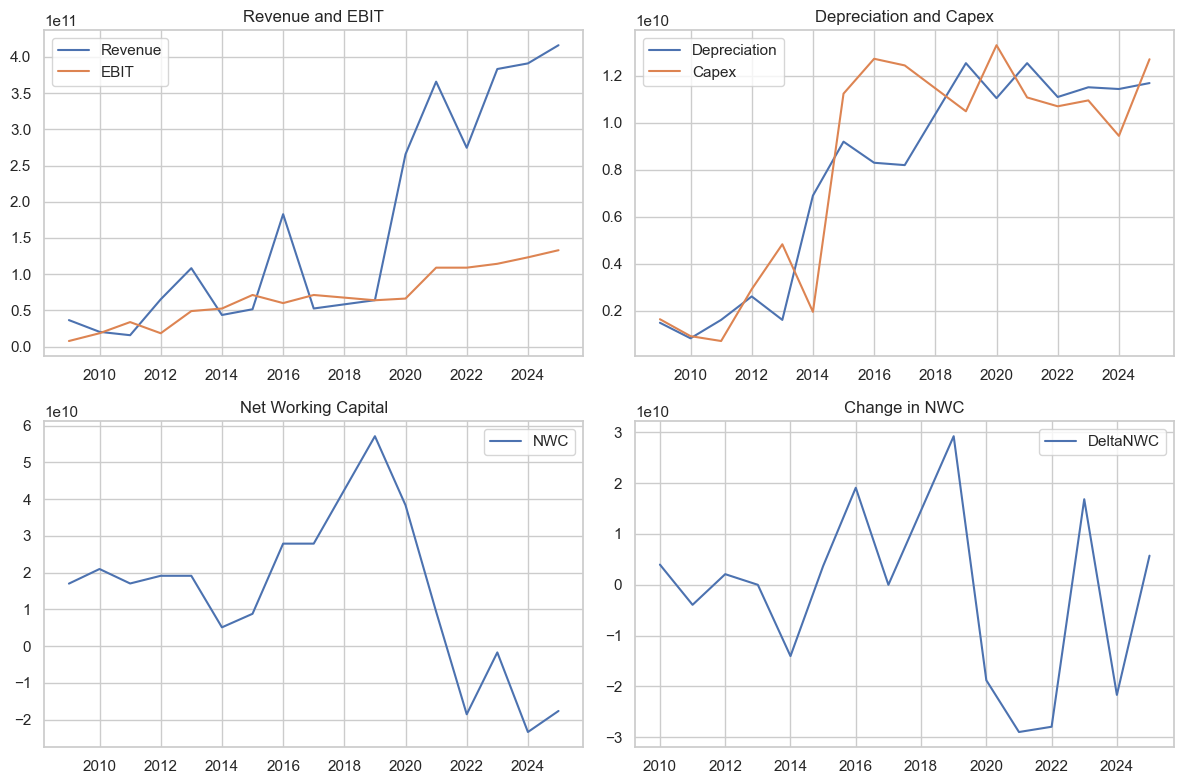

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

financial_history[["Revenue", "EBIT"]].plot(ax=axes[0])
axes[0].set_title("Revenue and EBIT")

financial_history[["Depreciation", "Capex"]].plot(ax=axes[1])
axes[1].set_title("Depreciation and Capex")

financial_history[["NWC"]].plot(ax=axes[2])
axes[2].set_title("Net Working Capital")

financial_history[["DeltaNWC"]].plot(ax=axes[3])
axes[3].set_title("Change in NWC")

fig.tight_layout()
plt.show()

## 4. Build disciplined assumptions

We anchor assumptions to the recent history and then apply sensible bounds. This keeps the model grounded and reduces the risk of aggressive forecasts.

Key inputs:
- revenue growth
- EBIT margin
- tax rate
- depreciation as a percent of revenue
- capex as a percent of revenue
- net working capital as a percent of revenue
- WACC (discount rate)
- terminal growth rate

In [24]:
recent_years = financial_history.tail(5)

def mean_or_default(series: pd.Series, default: float) -> float:
    series = series.replace([np.inf, -np.inf], np.nan).dropna()
    if series.empty:
        return default
    return float(series.mean())

revenue_growth = recent_years["Revenue"].pct_change().dropna()
ebit_margin = safe_ratio(recent_years["EBIT"], recent_years["Revenue"])
da_ratio = safe_ratio(recent_years["Depreciation"], recent_years["Revenue"])
capex_ratio = safe_ratio(recent_years["Capex"], recent_years["Revenue"])
nwc_ratio = safe_ratio(recent_years["NWC"], recent_years["Revenue"])

assumptions = {
    "revenue_growth": clip(mean_or_default(revenue_growth, 0.04), 0.01, 0.12),
    "ebit_margin": clip(mean_or_default(ebit_margin, 0.18), 0.05, 0.45),
    "tax_rate": 0.21,
    "da_ratio": clip(mean_or_default(da_ratio, 0.06), 0.01, 0.15),
    "capex_ratio": clip(mean_or_default(capex_ratio, 0.07), 0.01, 0.20),
    "nwc_ratio": clip(mean_or_default(nwc_ratio, 0.10), -0.05, 0.30),
    "wacc": 0.09,
    "terminal_growth": 0.025,
}

assumptions_df = pd.DataFrame(assumptions, index=["Base Case"]).T
assumptions_df.columns = ["Value"]
display(assumptions_df)

,Value
revenue_growth,0.06
ebit_margin,0.33
tax_rate,0.21
da_ratio,0.03
capex_ratio,0.03
nwc_ratio,-0.03
wacc,0.09
terminal_growth,0.03


## 5. Forecast free cash flow

We project revenue forward, apply margins and ratios, and compute free cash flow.

Formula:
$FCF = EBIT(1 - tax) + DA - Capex - ΔNWC$

In [25]:
forecast_years = 5
last_year = financial_history.index.max()
last_revenue = financial_history.loc[last_year, "Revenue"]

projection = []
revenue_level = last_revenue
nwc_level = assumptions["nwc_ratio"] * last_revenue

for year in range(1, forecast_years + 1):
    revenue_level = revenue_level * (1 + assumptions["revenue_growth"])
    ebit_level = revenue_level * assumptions["ebit_margin"]
    nopat = ebit_level * (1 - assumptions["tax_rate"])
    da_level = revenue_level * assumptions["da_ratio"]
    capex_level = revenue_level * assumptions["capex_ratio"]
    next_nwc = revenue_level * assumptions["nwc_ratio"]
    delta_nwc = next_nwc - nwc_level
    nwc_level = next_nwc
    fcf = nopat + da_level - capex_level - delta_nwc

    projection.append({
        "Year": last_year + year,
        "Revenue": revenue_level,
        "EBIT": ebit_level,
        "NOPAT": nopat,
        "Depreciation": da_level,
        "Capex": capex_level,
        "DeltaNWC": delta_nwc,
        "FCF": fcf,
    })

projection_df = pd.DataFrame(projection)
display(projection_df)

,Year,Revenue,EBIT,NOPAT,Depreciation,Capex,DeltaNWC,FCF
0,2026,"440,206,503,933.26","143,307,136,794.86","113,212,638,067.94","14,278,471,068.17","13,436,278,286.46","-716,398,370.87","114,771,229,220.52"
1,2027,"465,641,340,983.76","151,587,327,205.45","119,753,988,492.31","15,103,471,566.13","14,212,617,449.39","-757,791,389.07","121,402,633,998.11"
2,2028,"492,545,785,888.77","160,345,941,473.85","126,673,293,764.34","15,976,140,040.46","15,033,812,969.35","-801,576,068.14","128,417,196,903.60"
3,2029,"521,004,751,606.12","169,610,622,610.22","133,992,391,862.07","16,899,230,714.94","15,902,456,616.60","-847,890,596.65","135,837,056,557.06"
4,2030,"551,108,057,307.50","179,410,610,819.34","141,734,382,547.28","17,875,656,950.52","16,821,289,912.19","-896,881,147.60","143,685,630,733.22"


## 6. Discount cash flows and compute terminal value

We discount each forecast year and then apply a terminal value using the Gordon Growth model.

Terminal value:
$TV = \frac{FCF_{n+1}}{WACC - g}$

In [26]:
discount_factors = [(1 + assumptions["wacc"]) ** year for year in range(1, forecast_years + 1)]
projection_df["DiscountFactor"] = discount_factors
projection_df["PV_FCF"] = projection_df["FCF"] / projection_df["DiscountFactor"]

terminal_fcf = projection_df.iloc[-1]["FCF"] * (1 + assumptions["terminal_growth"])
terminal_value = terminal_fcf / (assumptions["wacc"] - assumptions["terminal_growth"])
pv_terminal = terminal_value / projection_df.iloc[-1]["DiscountFactor"]

enterprise_value = projection_df["PV_FCF"].sum() + pv_terminal

print(f"Enterprise Value (DCF): {enterprise_value:,.0f}")

Enterprise Value (DCF): 1,968,876,957,789


## 7. Equity value adjustment

Enterprise value includes all capital providers. To estimate equity value, subtract net debt.
We use the latest reported debt and cash if available; otherwise we allow a manual override.

In [27]:
cash = extract_tag_series(facts, ["CashAndCashEquivalentsAtCarryingValue", "CashCashEquivalentsAndShortTermInvestments"])
debt = extract_tag_series(facts, ["LongTermDebt", "LongTermDebtNoncurrent", "DebtLongterm"])
shares_out = extract_tag_series(facts, ["CommonStockSharesOutstanding"], unit="shares")

latest_cash = latest_value(cash) or 0.0
latest_debt = latest_value(debt) or 0.0
net_debt = latest_debt - latest_cash

equity_value = enterprise_value - net_debt
print(f"Net debt estimate: {net_debt:,.0f}")
print(f"Equity value (DCF): {equity_value:,.0f}")

if not shares_out.empty:
    latest_shares = latest_value(shares_out)
    if latest_shares:
        per_share = equity_value / latest_shares
        print(f"Equity value per share: {per_share:,.2f}")
else:
    print("Shares outstanding not available in this dataset.")

Net debt estimate: 54,744,000,000
Equity value (DCF): 1,914,132,957,789
Equity value per share: 129.57


## 8. Sensitivity analysis

We stress the two most sensitive assumptions: WACC and terminal growth. This helps confirm whether the valuation is robust to reasonable changes.

In [28]:
wacc_range = np.linspace(assumptions["wacc"] - 0.02, assumptions["wacc"] + 0.02, 5)
terminal_range = np.linspace(assumptions["terminal_growth"] - 0.01, assumptions["terminal_growth"] + 0.01, 5)

sensitivity = pd.DataFrame(index=[f"{g:.2%}" for g in terminal_range], columns=[f"{w:.2%}" for w in wacc_range])

for g in terminal_range:
    for w in wacc_range:
        pv_fcf = (projection_df["FCF"] / (1 + w) ** np.arange(1, forecast_years + 1)).sum()
        tv = (projection_df.iloc[-1]["FCF"] * (1 + g)) / (w - g)
        pv_tv = tv / (1 + w) ** forecast_years
        sensitivity.loc[f"{g:.2%}", f"{w:.2%}"] = pv_fcf + pv_tv

display(sensitivity)

,7.00%,8.00%,9.00%,10.00%,11.00%
1.50%,"2,414,794,531,757.51","2,036,957,743,000.43","1,760,075,884,395.79","1,548,509,563,197.81","1,381,625,866,066.89"
2.00%,"2,614,098,313,078.24","2,172,359,317,368.13","1,857,019,239,899.81","1,620,670,753,737.08","1,436,976,845,893.51"
2.50%,"2,857,691,823,581.35","2,332,379,359,802.67","1,968,876,957,789.06","1,702,453,436,348.25","1,498,839,705,699.74"
3.00%,"3,162,183,711,710.24","2,524,403,410,724.13","2,099,377,628,659.85","1,795,919,359,332.45","1,568,435,422,981.75"
3.50%,"3,553,673,282,161.67","2,759,099,472,961.47","2,253,605,694,234.42","1,903,764,655,083.44","1,647,310,569,234.69"


## 9. Multi-company comparison

Below we run the same DCF framework for AAPL, MSFT, and NVDA, then compare the implied per-share value to the latest market price. If public feeds are blocked, you can provide manual price overrides in the cell below.

In [32]:
tickers = ["AAPL", "MSFT", "NVDA"]
price_overrides = {
    # Optional manual overrides if market feeds are blocked.
    # "AAPL": 0.0,
    # "MSFT": 0.0,
    # "NVDA": 0.0,
}

summaries = []
for name in tickers:
    summaries.append(compute_dcf_summary(name, price_overrides.get(name)))

comparison = pd.DataFrame(summaries)
comparison["Implied_Upside"] = comparison["Implied_Upside"].map(lambda x: f"{x:.1%}" if pd.notna(x) else None)
comparison["DCF_PerShare"] = comparison["DCF_PerShare"].map(lambda x: f"{x:,.2f}" if pd.notna(x) else None)
comparison["MarketPrice"] = comparison["MarketPrice"].map(lambda x: f"{x:,.2f}" if pd.notna(x) else None)

comparison = comparison[[
    "Ticker",
    "Last_FY",
    "DCF_PerShare",
    "MarketPrice",
    "Implied_Upside",
    "Imputed_Items",
]]

comparison

/var/folders/07/l8m36_9s2lz170jptjv7r6jc0000gn/T/ipykernel_9790/1806559045.py:157: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  ebit = operating_income.combine_first(pre_tax_income)
/var/folders/07/l8m36_9s2lz170jptjv7r6jc0000gn/T/ipykernel_9790/1806559045.py:157: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  ebit = operating_income.combine_first(pre_tax_income)
/var/folders/07/l8m36_9s2lz170jptjv7r6jc0000gn/T/ipykernel_9790/1806559045.py:157: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this 

,Ticker,Last_FY,DCF_PerShare,MarketPrice,Implied_Upside,Imputed_Items
0,AAPL,2025,129.57,None,None,7
1,MSFT,2025,180.50,None,None,0
2,NVDA,2022,9.22,None,None,0


## 10. Final notes

A DCF is a structured decision tool, not a precise prediction. Keep it robust by:
- validating the data sources
- documenting assumptions
- running sensitivity tests
- comparing results to market multiples

You can extend this notebook by adding detailed debt schedules, segment-level projections, or scenario analysis.